In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
np.set_printoptions(precision=2)

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

d:\Programs\Machine_Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "andonians/random-linear-regression",
  "test.csv",
  # Provide any additional arguments like 
  # sql_query or pandas_kwargs. See the 
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

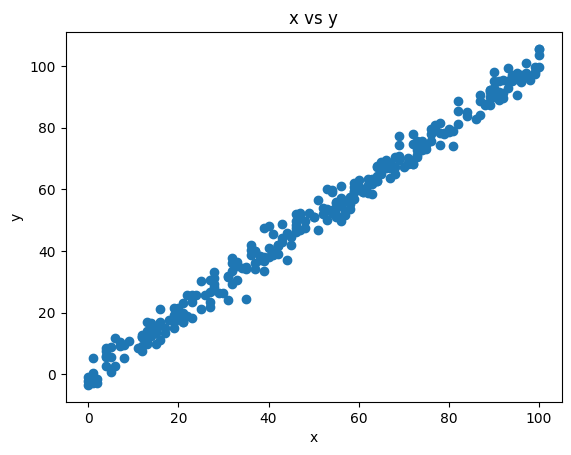

In [4]:
plt.scatter(df["x"], df["y"])

plt.xlabel("x")
plt.ylabel("y")
plt.title("x vs y")

plt.show()

In [7]:
df_subset = df[["x", "y"]]

X = df[["x"]]
y= df["y"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train = X_train.values.flatten()
y_train = y_train.values

print(X_train.shape, y_train.shape)
print(X_train[:5], y_train[:5])

(240,) (240,)
[88 57 62  4 56] [87.37 56.15 58.87  6.08 54.55]


In [57]:
def compute_cost(X, y, w, b):

    m=X.shape[0]
    total_cost = 0

    for i in range(m):
        f_wb = w * X[i] + b
        total_cost = total_cost + (f_wb - y[i])**2
    total_cost = total_cost/(2*m)

    return total_cost

def compute_gradient(X, y, w, b):
    m = X.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * X[i] + b
        dj_dw_i = (f_wb - y[i]) * X[i]
        dj_db_i = (f_wb - y[i])
        dj_dw += dj_dw_i
        dj_db += dj_db_i
    dj_dw = dj_dw/m
    dj_db = dj_db/m

    return dj_dw, dj_db

def linear_regression(X, y, w_in, b_in, alpha, num_iters):
    J_history = []
    p_history = []
    b = b_in
    w = w_in

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w -= alpha * dj_dw
        b -= alpha * dj_db

        if i<100000:
            J_history.append(compute_cost(X, y, w, b))
            p_history.append([w, b])

    return w, b, J_history, p_history
    
def measure(y, y_pred):
    mse = np.mean((y_pred - y) ** 2)
    rmse = np.sqrt(mse)
    print(f"MSE: {mse}, RMSE: {rmse}")

def predict(X, w, b):
    m = X.shape[0]
    f_wb = np.zeros(m)

    for i in range(m):
        f_wb[i] = w * X[i] + b

    return f_wb

In [58]:
w_init = 0
b_init = 0

iterations = 10000
temp_alpha = 1.0e-4

w_final, b_final, J_hist, p_hist = linear_regression(X_train, y_train, w_init, b_init, temp_alpha, iterations)
y_pred = predict(X_test.values.flatten(), w_final, b_final)
measure(y_test.values, y_pred)
print(f"w_final: {w_final}, b_final: {b_final}")

MSE: 9.355354350370366, RMSE: 3.0586523748818477
w_final: 1.0089533306266012, b_final: -0.06131105764878158


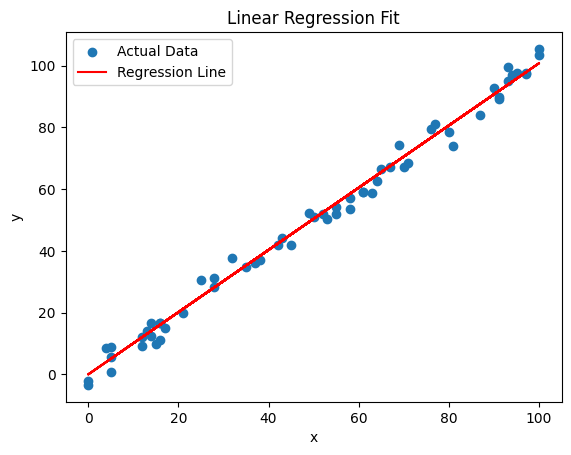

In [60]:
plt.scatter(X_test, y_test, label="Actual Data")
plt.plot(X_test, y_pred, color="red", label="Regression Line")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.legend()

plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train.reshape(-1, 1), y_train)
y_pred_sklearn = model.predict(X_test.reshape(-1, 1))
measure(y_test.values, y_pred_sklearn)

ValueError: Expected 2D array, got 1D array instead:
array=[ 88  57  62   4  56  99  89  89  39  54  89  78  37  91  29  64  56  40
  41  43  16  63  69  41  84  66  13  79  15   4  61  82  55  96  69  65
  72  60  58  50  14  13  31  91  20  39  71  87  97  21  12  45  82  90
  31  17  99  41  72  40   0  54  37  66  53  60  28  47  99  21  59  94
  21  90  23   8  22  58  46  22  24   9  32  64  23  16  20  15  27  48
  72  90  42  33  19  68  48  18  19  39  44   7  96  47  93  73  59  65
  80  88  14  67  86  71  43  44  65  79   1  97  78  77  55  56   2  36
  78  37  73  53  72  60  56  74  54  19  46  34  21   4  36  98  33  66
  54  75  19  64  76  30  89  92  20  46  57  82   4  23  81  91  12   6
  55  84  27 100  41  27  77  59  33  92  11  67  57  36  68  60  73  87
  72  26  46  76  95  63  92   7  95  20  12  31  25  21  75  74  35  68
  13  28  38  52  46  62  59  95   8  28  42  39  59  94   1  46  62  51
  35  69  40  74  56  51  42  96  73   6   2  64  32  32 100  23 